# Gradient Boosting Model Development and Optimization

**Project:** U.S. Residential Rental Price Estimation  
**Individual contribution:** H.B. Janeesha Pabasara

### Objectives

- Develop a Gradient Boosting regression model for rental price prediction.
- Apply five-fold cross-validation while preventing data leakage.
- Establish a baseline and measure MAE, RMSE, and R².
- Investigate overfitting through training and validation errors.
- Compare controlled hyperparameter configurations.
- Analyse feature importance and prediction errors.
- Select and save the final Gradient Boosting model for integration.

## 1. Baseline Gradient Boosting Model


### 1.1 Loading the Raw Training and Test Data

The shared preprocessing notebook exports cleaned `raw_train.csv` and `raw_test.csv`. These retain original feature values so model-specific encoders and imputers can be fitted inside cross-validation.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
train_path = project_root / 'data' / 'raw_train.csv'
test_path = project_root / 'data' / 'raw_test.csv'
if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError('Run 02_Preprocessing.ipynb to create data/raw_train.csv and data/raw_test.csv first.')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print('Training shape:', train_df.shape)
print('Test shape:', test_df.shape)
display(train_df.head())

Training shape: (143679, 17)
Test shape: (35920, 17)


,region,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,lat,long,state,price
0,binghamton,apartment,1700,3,1.0,0,0,0,0,0,0,w/d hookups,Unknown,42.0953,-75.9269,ny,985
1,sarasota-bradenton,apartment,840,1,1.0,0,0,1,0,0,0,Unknown,Unknown,27.2427,-82.4751,fl,1210
2,"quad cities, IA/IL",apartment,940,2,1.0,0,0,0,0,0,0,laundry on site,street parking,41.4906,-90.4980,il,775
3,seattle-tacoma,house,900,2,1.0,0,0,1,0,0,0,Unknown,Unknown,47.6339,-122.3480,wa,1650
4,tyler / east TX,apartment,775,2,1.0,0,0,1,0,0,0,w/d in unit,off-street parking,31.9563,-95.2691,tx,685


### 1.2 Defining the Features and Target

`price` is monthly rent in U.S. dollars. It is removed from the predictors to avoid direct target leakage. The test split is reserved for final comparison.


In [2]:
X = train_df.drop(columns=['price'])
y = train_df['price']
X_test = test_df.drop(columns=['price'])
y_test = test_df['price']
print('Training features and target:', X.shape, y.shape)
print('Test features and target:', X_test.shape, y_test.shape)

Training features and target: (143679, 16) (143679,)
Test features and target: (35920, 16) (35920,)


### 1.3 Cross-Validation Strategy

**Why five folds?** Each training row is validated once while four-fifths of the data are used to fit each model. The average is less dependent on one split. Shuffling and a fixed seed make the folds reproducible. Every configuration uses identical folds. Region encoding and preprocessing are learned separately within each fold. Five-fold results should not be directly compared to Thiwanka's three-fold averages; use the shared test split for the group comparison.


In [3]:
from sklearn.model_selection import KFold

RANDOM_STATE = 42
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Number of cross-validation folds:', kf.get_n_splits(X))

Number of cross-validation folds: 5


### 1.4 Define Feature Groups

The cleaned split contains numerical, low-cardinality categorical, binary, and high-cardinality `region` features. Region is encoded separately because one-hot encoding hundreds of regions would expand the input considerably.


In [4]:
numerical_features = ['sqfeet', 'beds', 'baths', 'lat', 'long']
categorical_features = ['type', 'laundry_options', 'parking_options', 'state']
binary_features = [
    'cats_allowed', 'dogs_allowed', 'smoking_allowed',
    'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished'
]
required_features = numerical_features + ['region'] + categorical_features + binary_features
for label, frame in [('train', X), ('test', X_test)]:
    missing = set(required_features) - set(frame.columns)
    if missing:
        raise ValueError(f'{label} split is missing: {sorted(missing)}')
print('Numerical:', numerical_features)
print('Categorical:', categorical_features)
print('Binary:', binary_features)

Numerical: ['sqfeet', 'beds', 'baths', 'lat', 'long']
Categorical: ['type', 'laundry_options', 'parking_options', 'state']
Binary: ['cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished']


### 1.5 Build the Preprocessing Pipeline

Numerical values use median imputation. Scaling is unnecessary for tree-based Gradient Boosting because tree splits depend on value ordering. Low-cardinality categories use most-frequent imputation and one-hot encoding. Binary flags pass through unchanged.


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
print('Numerical and categorical pipelines are ready.')

Numerical and categorical pipelines are ready.


### 1.6 Leakage-Safe Target Encoding for Region

Region is represented by a smoothed mean rent. For an outer validation fold, the mapping is learned only from its training fold. Within that training fold, an inner five-fold split gives each training row an out-of-fold region value, so its own price does not determine its encoding. Unknown regions use the training mean.


In [6]:
def learn_region_mapping(features, target, smoothing=10):
    global_mean = float(target.mean())
    stats = pd.DataFrame({
        'region': features['region'].to_numpy(),
        'target': target.to_numpy()
    }).groupby('region')['target'].agg(['mean', 'count'])
    stats['encoded'] = (
        stats['count'] * stats['mean'] + smoothing * global_mean
    ) / (stats['count'] + smoothing)
    return stats['encoded'].to_dict(), global_mean

def encode_region(features, mapping, global_mean):
    encoded = features.copy()
    encoded['region_encoded'] = encoded['region'].map(mapping).fillna(global_mean)
    return encoded.drop(columns=['region'])

In [7]:
def out_of_fold_region_encoding(features, target):
    inner_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    encoded_values = pd.Series(index=features.index, dtype=float)
    for fit_idx, holdout_idx in inner_kf.split(features):
        mapping, fallback = learn_region_mapping(
            features.iloc[fit_idx], target.iloc[fit_idx]
        )
        encoded_values.iloc[holdout_idx] = (
            features.iloc[holdout_idx]['region']
            .map(mapping).fillna(fallback).to_numpy()
        )
    result = features.copy()
    result['region_encoded'] = encoded_values.to_numpy()
    return result.drop(columns=['region'])

### 1.7 Preprocessing After Target Encoding

Once `region` becomes numeric `region_encoded`, the four remaining text categories can be one-hot encoded. The same feature lists are used in every fold and in final training.


In [8]:
processed_numerical_features = numerical_features + ['region_encoded']
other_categorical_features = categorical_features.copy()
print('Processed numerical:', processed_numerical_features)
print('One-hot categorical:', other_categorical_features)

Processed numerical: ['sqfeet', 'beds', 'baths', 'lat', 'long', 'region_encoded']
One-hot categorical: ['type', 'laundry_options', 'parking_options', 'state']


### 1.8 Combining the Preprocessing Components

The `ColumnTransformer` combines imputed numerical features, one-hot categorical features, and binary flags. A fresh clone is fitted in each outer fold.


In [9]:
from sklearn.base import clone

preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, processed_numerical_features),
    ('categorical', categorical_pipeline, other_categorical_features),
    ('binary', 'passthrough', binary_features)
])
print('Preprocessor created.')

Preprocessor created.


### 1.9 Cross-Validation Training and Evaluation

The baseline is trained five times, once per fold. Training and validation errors are recorded separately to examine generalization.


In [10]:
fold_indices = list(kf.split(X))
fold_results = []
print('Prepared folds:', len(fold_indices))
print('First fold train/validation rows:', len(fold_indices[0][0]), len(fold_indices[0][1]))

Prepared folds: 5
First fold train/validation rows: 114943 28736


### 1.10 Applying Fold-Specific Preprocessing

The helper creates out-of-fold region values for training rows, encodes validation rows using the complete outer training fold, then fits imputation and one-hot encoding only on the outer training fold.


In [11]:
def prepare_fold(train_index, valid_index):
    X_fold_train = X.iloc[train_index].reset_index(drop=True)
    X_fold_valid = X.iloc[valid_index].reset_index(drop=True)
    y_fold_train = y.iloc[train_index].reset_index(drop=True)
    y_fold_valid = y.iloc[valid_index].reset_index(drop=True)

    encoded_train = out_of_fold_region_encoding(X_fold_train, y_fold_train)
    mapping, fallback = learn_region_mapping(X_fold_train, y_fold_train)
    encoded_valid = encode_region(X_fold_valid, mapping, fallback)

    fold_preprocessor = clone(preprocessor)
    processed_train = fold_preprocessor.fit_transform(encoded_train)
    processed_valid = fold_preprocessor.transform(encoded_valid)
    return processed_train, processed_valid, y_fold_train, y_fold_valid

### 1.11 Preparing the Target Variable

The rental price is right-skewed. Fit the model to `log1p(price)` and return predictions to dollars with `expm1` before measuring error.


In [12]:
def transform_target(target):
    if target.isna().any() or (target < 0).any():
        raise ValueError('The target must be complete and non-negative.')
    return np.log1p(target.to_numpy())

print('Example original prices:', y.head(3).to_list())
print('Example log prices:', transform_target(y.head(3)))

Example original prices: [985, 1210, 775]
Example log prices: [6.89365635 7.09920174 6.65415252]


### 1.12 Training the Gradient Boosting Model

The baseline uses 100 boosting stages, learning rate 0.1, and depth-three trees. A fixed seed supports reproducibility.


In [13]:
from sklearn.ensemble import GradientBoostingRegressor

baseline_params = dict(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    min_samples_leaf=1, subsample=1.0, random_state=RANDOM_STATE
)

def train_gbr(processed_train, target, parameters):
    model = GradientBoostingRegressor(**parameters)
    model.fit(processed_train, transform_target(target))
    return model

print('Baseline parameters:', baseline_params)

Baseline parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'subsample': 1.0, 'random_state': 42}


### 1.13 Generating Predictions

The regressor predicts log rent. The inverse transformation returns predicted monthly rent in dollars. Tiny negative outputs are clipped to zero.


In [14]:
def predict_dollars(model, processed_features):
    prediction_log = model.predict(processed_features)
    return np.maximum(0, np.expm1(prediction_log))

### 1.14 Evaluating Model Performance

MAE and RMSE are in dollars; lower is better. R² measures explained variation; higher is better. A large validation-versus-training RMSE gap can indicate overfitting.


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score_predictions(actual, predicted):
    return dict(
        MAE=mean_absolute_error(actual, predicted),
        RMSE=np.sqrt(mean_squared_error(actual, predicted)),
        R2=r2_score(actual, predicted)
    )

In [16]:
for fold, (train_index, valid_index) in enumerate(fold_indices, start=1):
    X_train_fold, X_valid_fold, y_train_fold, y_valid_fold = prepare_fold(
        train_index, valid_index
    )
    fold_model = train_gbr(X_train_fold, y_train_fold, baseline_params)
    train_scores = score_predictions(
        y_train_fold, predict_dollars(fold_model, X_train_fold)
    )
    valid_scores = score_predictions(
        y_valid_fold, predict_dollars(fold_model, X_valid_fold)
    )
    fold_results.append({
        'Fold': fold, 'Train_RMSE': train_scores['RMSE'],
        **valid_scores, 'RMSE_Gap': valid_scores['RMSE'] - train_scores['RMSE']
    })
    print(f"Fold {fold}: MAE=${valid_scores['MAE']:.2f}, "
          f"RMSE=${valid_scores['RMSE']:.2f}, R²={valid_scores['R2']:.4f}")

results_df = pd.DataFrame(fold_results)
display(results_df.round(4))

Fold 1: MAE=$234.88, RMSE=$388.51, R²=0.6615
Fold 2: MAE=$234.99, RMSE=$388.90, R²=0.6631
Fold 3: MAE=$236.10, RMSE=$398.12, R²=0.6556
Fold 4: MAE=$238.31, RMSE=$398.83, R²=0.6518
Fold 5: MAE=$235.81, RMSE=$389.14, R²=0.6660


,Fold,Train_RMSE,MAE,RMSE,R2,RMSE_Gap
0,1,389.2971,234.8833,388.5098,0.6615,-0.7873
1,2,389.5612,234.9946,388.9030,0.6631,-0.6582
2,3,388.6481,236.1011,398.1194,0.6556,9.4713
3,4,390.8743,238.3104,398.8289,0.6518,7.9546
4,5,391.8247,235.8092,389.1431,0.6660,-2.6816


In [17]:
cv_mean = results_df[['MAE', 'RMSE', 'R2', 'Train_RMSE', 'RMSE_Gap']].mean()
cv_std = results_df[['MAE', 'RMSE', 'R2']].std()
print('Five-fold baseline mean:')
print(cv_mean.round(4))
print('Five-fold validation standard deviation:')
print(cv_std.round(4))

Five-fold baseline mean:
MAE           236.0197
RMSE          392.7008
R2              0.6596
Train_RMSE    390.0411
RMSE_Gap        2.6598
dtype: float64
Five-fold validation standard deviation:
MAE     1.3821
RMSE    5.2811
R2      0.0058
dtype: float64


### 1.15 Final Baseline Training and Test Evaluation

The baseline is fitted on the complete training split. Its test result is a descriptive reference for the predeclared tuning search. Parameter selection uses training cross-validation results; test scores must not be used to revise the search choices.


In [18]:
X_full = train_df.drop(columns=['price']).reset_index(drop=True)
y_full = train_df['price'].reset_index(drop=True)
X_test_final = test_df.drop(columns=['price']).reset_index(drop=True)
y_test_final = test_df['price'].reset_index(drop=True)
print('Full training:', X_full.shape, 'Test:', X_test_final.shape)

Full training: (143679, 16) Test: (35920, 16)


In [19]:
X_full_encoded = out_of_fold_region_encoding(X_full, y_full)
region_mapping, region_global_mean = learn_region_mapping(X_full, y_full)
X_test_encoded = encode_region(X_test_final, region_mapping, region_global_mean)
print('Encoded training:', X_full_encoded.shape)
print('Encoded test:', X_test_encoded.shape)
print('Known regions:', len(region_mapping))

Encoded training: (143679, 16)
Encoded test: (35920, 16)
Known regions: 404


### 1.16 Final Training Data Preprocessing

Fit the preprocessor on the complete training split and transform the test split with those fitted values and categories.


In [20]:
final_preprocessor = clone(preprocessor)
X_full_processed = final_preprocessor.fit_transform(X_full_encoded)
X_test_processed = final_preprocessor.transform(X_test_encoded)
print('Processed training:', X_full_processed.shape)
print('Processed test:', X_test_processed.shape)
print('Missing processed values:', np.isnan(X_full_processed).sum())

Processed training: (143679, 89)
Processed test: (35920, 89)
Missing processed values: 0


### 1.17 Preparing the Target Variable for Final Training

Only the training target is log transformed. The test target remains in dollars for evaluation.


In [21]:
y_full_log = transform_target(y_full)
y_test_original = y_test_final.to_numpy()
print('Log-training target:', y_full_log.shape)
print('Original test target:', y_test_original.shape)

Log-training target: (143679,)
Original test target: (35920,)


### 1.18 Training the Final Baseline Gradient Boosting Model

Use the same baseline hyperparameters as in cross-validation.


In [22]:
final_baseline_model = GradientBoostingRegressor(**baseline_params)
final_baseline_model.fit(X_full_processed, y_full_log)
print('Final baseline Gradient Boosting model trained.')

Final baseline Gradient Boosting model trained.


### 1.19 Generating Predictions on the Test Set

Convert baseline predictions from log rent back to monthly rent in dollars.


In [23]:
baseline_test_log = final_baseline_model.predict(X_test_processed)
baseline_test_pred = np.maximum(0, np.expm1(baseline_test_log))
print('Predictions:', len(baseline_test_pred))
print('First five:', baseline_test_pred[:5].round(2))

Predictions: 35920
First five: [1376.54 2951.9   840.25  746.41 1343.03]


### 1.20 Final Baseline Test Set Evaluation

These test metrics describe performance on unseen listings. They do not decide the tuning configuration.


In [24]:
baseline_test_scores = score_predictions(y_test_original, baseline_test_pred)
print('Baseline test MAE:  ${:,.2f}'.format(baseline_test_scores['MAE']))
print('Baseline test RMSE: ${:,.2f}'.format(baseline_test_scores['RMSE']))
print('Baseline test R²:   {:.4f}'.format(baseline_test_scores['R2']))

Baseline test MAE:  $234.90
Baseline test RMSE: $390.10
Baseline test R²:   0.6564


### 1.21 Summary of Final Baseline Model Performance

The table records computed baseline results. Compare test RMSE with the cross-validation mean to assess generalization. Write your interpretation after running the notebook.


In [25]:
baseline_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'CV mean': [cv_mean['MAE'], cv_mean['RMSE'], cv_mean['R2']],
    'Test': [baseline_test_scores['MAE'], baseline_test_scores['RMSE'], baseline_test_scores['R2']]
})
display(baseline_summary.round(4))

,Metric,CV mean,Test
0,MAE,236.0197,234.8960
1,RMSE,392.7008,390.1042
2,R2,0.6596,0.6564


### 1.22 Feature Importance Analysis

Gradient Boosting reports impurity-based importance for processed features. Importance reflects model use, not causation. Correlated features can share importance.


In [26]:
feature_names = final_preprocessor.get_feature_names_out()
importance_values = final_baseline_model.feature_importances_
feature_importance_df = (pd.DataFrame({
    'Feature': feature_names, 'Importance': importance_values
}).sort_values('Importance', ascending=False).reset_index(drop=True))
display(feature_importance_df.head(20))

,Feature,Importance
0,numerical__region_encoded,0.637835
1,numerical__sqfeet,0.184715
2,categorical__laundry_options_w/d in unit,0.049962
3,numerical__baths,0.047436
4,categorical__parking_options_attached garage,0.018584
5,categorical__type_house,0.010696
6,categorical__type_cottage/cabin,0.008186
7,binary__smoking_allowed,0.007870
8,numerical__long,0.006474
9,categorical__laundry_options_Unknown,0.005146


### 1.23 Visualizing Feature Importance

A horizontal chart makes the top 20 processed predictors easy to compare.


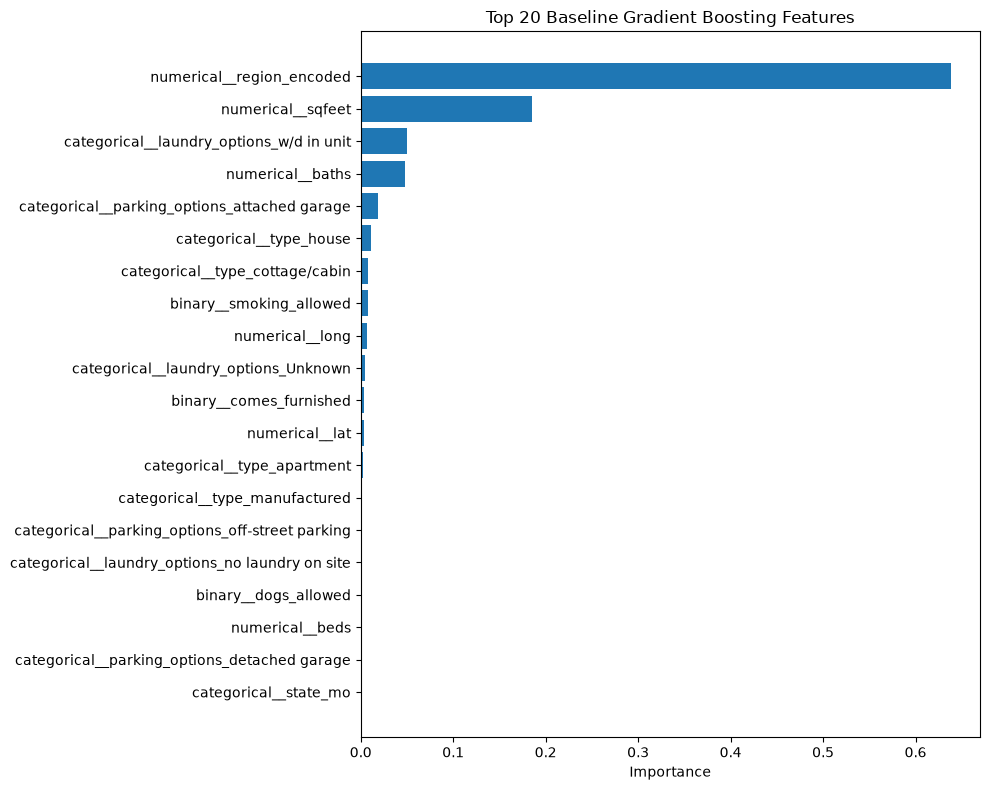

In [27]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(20).sort_values('Importance')
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 20 Baseline Gradient Boosting Features')
plt.tight_layout()
plt.show()

### 1.24 Interpretation of Feature Importance

After running the chart, state which features rank highest and explain why they may help prediction. For example, `region_encoded` summarizes historical location prices, and `sqfeet` describes property size. Do not claim their rank or exact importance before seeing the output.


### 1.25 Actual vs Predicted Rental Prices

The diagonal marks perfect prediction. Scatter away from it shows the size and direction of individual errors.


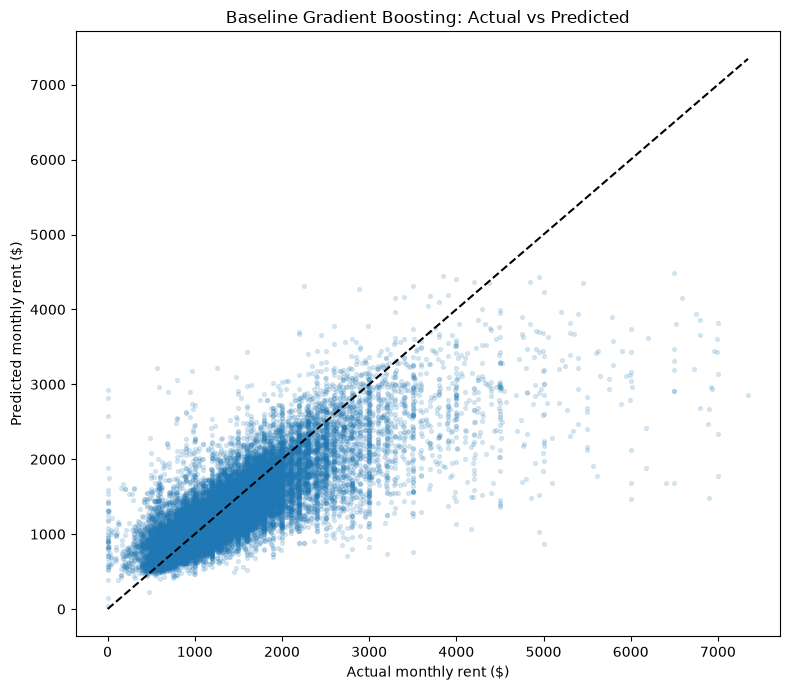

In [28]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test_original, baseline_test_pred, alpha=0.15, s=8)
plot_min = min(y_test_original.min(), baseline_test_pred.min())
plot_max = max(y_test_original.max(), baseline_test_pred.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], '--', color='black')
plt.xlabel('Actual monthly rent ($)')
plt.ylabel('Predicted monthly rent ($)')
plt.title('Baseline Gradient Boosting: Actual vs Predicted')
plt.tight_layout()
plt.show()

### 1.26 Interpretation of Actual vs Predicted Results

Describe the observed concentration around the diagonal and identify price ranges with large errors. A model may predict common rents well while missing rare expensive listings. Base the interpretation on your plot.


### 1.27 Residual Analysis

Residual = actual rent minus predicted rent. Positive values mean underprediction; negative values mean overprediction.


In [29]:
baseline_residuals = y_test_original - baseline_test_pred
print('Mean residual:  ${:,.2f}'.format(baseline_residuals.mean()))
print('Median residual: ${:,.2f}'.format(np.median(baseline_residuals)))
print('Residual std:   ${:,.2f}'.format(baseline_residuals.std()))

Mean residual:  $55.83
Median residual: $13.19
Residual std:   $386.09


### 1.28 Residual Distribution

The histogram shows whether most errors cluster near zero and whether one tail is much longer.


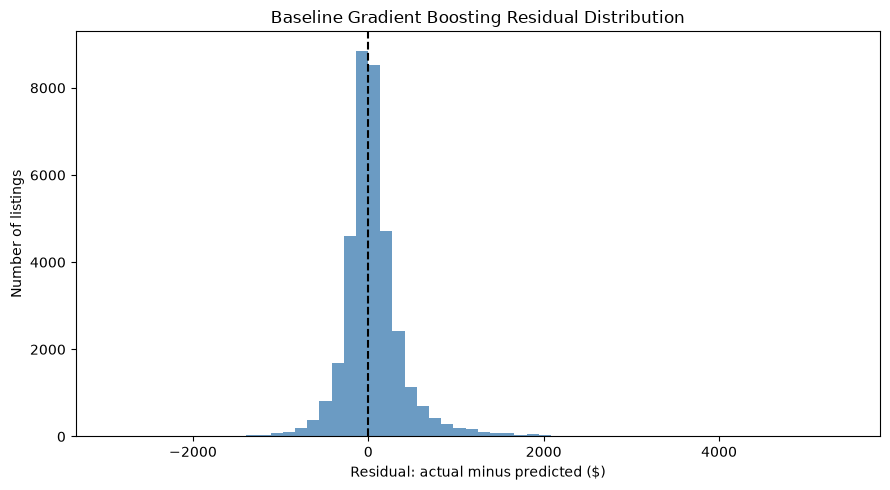

In [30]:
plt.figure(figsize=(9, 5))
plt.hist(baseline_residuals, bins=60, color='steelblue', alpha=0.8)
plt.axvline(0, linestyle='--', color='black')
plt.xlabel('Residual: actual minus predicted ($)')
plt.ylabel('Number of listings')
plt.title('Baseline Gradient Boosting Residual Distribution')
plt.tight_layout()
plt.show()

### 1.28a Interpretation of Residual Distribution

Explain the center, spread, and any long tail you observe. A long positive tail would mean some actual rents are much higher than predicted.


### 1.29 Residuals vs Predicted Rental Prices

This plot can expose changing error spread or systematic underprediction at higher estimated rents.


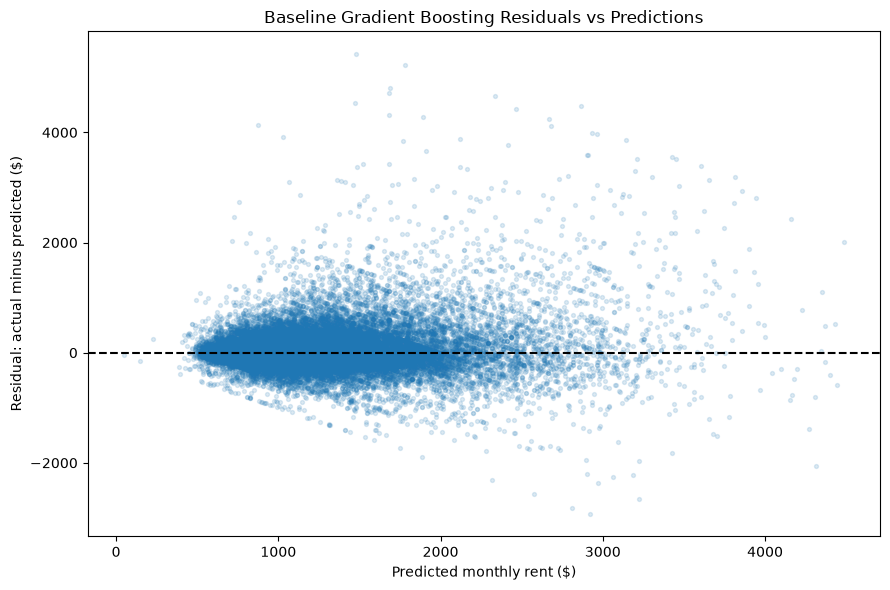

In [31]:
plt.figure(figsize=(9, 6))
plt.scatter(baseline_test_pred, baseline_residuals, alpha=0.15, s=8)
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('Predicted monthly rent ($)')
plt.ylabel('Residual: actual minus predicted ($)')
plt.title('Baseline Gradient Boosting Residuals vs Predictions')
plt.tight_layout()
plt.show()

### 1.30 Interpretation of Residuals vs Predicted Prices

Describe whether residuals are balanced around zero and whether their spread increases at higher predicted rents. Use what the plot shows; avoid a fixed conclusion.


### 1.31 Final Gradient Boosting Baseline Model Summary

Record the five-fold mean and spread from Section 1.14 and baseline test metrics from Section 1.20. Compare mean training RMSE with validation RMSE to discuss overfitting. The tuning experiment below tests whether another configuration improves validation performance.


## 2. Hyperparameter Tuning

The same five outer folds, encoding rules, target transform, and metrics are used for every candidate. Selection uses mean cross-validation RMSE, with MAE and fold spread as checks. The tested choices are specified before inspecting tuning results.


### 2.1 Defining Candidate Hyperparameter Configurations

`n_estimators` controls tree count, `learning_rate` controls each tree's contribution, `max_depth` limits interaction complexity, `min_samples_leaf` smooths predictions, and `subsample` introduces row sampling. These three candidates form a compact controlled search.


In [32]:
tuning_configs = {
    'Tuned_1': dict(n_estimators=150, learning_rate=0.05, max_depth=3,
                    min_samples_leaf=5, subsample=0.8, random_state=RANDOM_STATE),
    'Tuned_2': dict(n_estimators=200, learning_rate=0.05, max_depth=2,
                    min_samples_leaf=5, subsample=0.8, random_state=RANDOM_STATE),
    'Tuned_3': dict(n_estimators=150, learning_rate=0.05, max_depth=4,
                    min_samples_leaf=10, subsample=0.8, random_state=RANDOM_STATE)
}
display(pd.DataFrame(tuning_configs).T)

,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,random_state
Tuned_1,150.0,0.05,3.0,5.0,0.8,42.0
Tuned_2,200.0,0.05,2.0,5.0,0.8,42.0
Tuned_3,150.0,0.05,4.0,10.0,0.8,42.0


### 2.2 Hyperparameter Search

In each fold, fit the same fold-specific preprocessing once, then train every candidate on those features. The baseline's five-fold results are reused from Section 1.14.


In [33]:
tuning_records = []
for fold, (train_index, valid_index) in enumerate(fold_indices, start=1):
    X_train_fold, X_valid_fold, y_train_fold, y_valid_fold = prepare_fold(
        train_index, valid_index
    )
    for name, parameters in tuning_configs.items():
        model = train_gbr(X_train_fold, y_train_fold, parameters)
        train_scores = score_predictions(
            y_train_fold, predict_dollars(model, X_train_fold)
        )
        valid_scores = score_predictions(
            y_valid_fold, predict_dollars(model, X_valid_fold)
        )
        tuning_records.append({
            'Configuration': name, 'Fold': fold, 'Train_RMSE': train_scores['RMSE'],
            **valid_scores, 'RMSE_Gap': valid_scores['RMSE'] - train_scores['RMSE']
        })
        print(f"Fold {fold} / {name}: RMSE=${valid_scores['RMSE']:.2f}")

tuning_fold_df = pd.DataFrame(tuning_records)
display(tuning_fold_df.round(4))

Fold 1 / Tuned_1: RMSE=$394.52
Fold 1 / Tuned_2: RMSE=$403.65
Fold 1 / Tuned_3: RMSE=$383.53
Fold 2 / Tuned_1: RMSE=$394.48
Fold 2 / Tuned_2: RMSE=$403.61
Fold 2 / Tuned_3: RMSE=$383.85
Fold 3 / Tuned_1: RMSE=$403.27
Fold 3 / Tuned_2: RMSE=$411.84
Fold 3 / Tuned_3: RMSE=$390.97
Fold 4 / Tuned_1: RMSE=$403.54
Fold 4 / Tuned_2: RMSE=$412.35
Fold 4 / Tuned_3: RMSE=$390.55
Fold 5 / Tuned_1: RMSE=$394.63
Fold 5 / Tuned_2: RMSE=$403.92
Fold 5 / Tuned_3: RMSE=$382.69


,Configuration,Fold,Train_RMSE,MAE,RMSE,R2,RMSE_Gap
0,Tuned_1,1,395.5646,238.9705,394.5196,0.6510,-1.0450
1,Tuned_2,1,406.0201,245.0885,403.6513,0.6346,-2.3688
2,Tuned_3,1,382.4838,231.3331,383.5288,0.6701,1.0449
3,Tuned_1,2,396.8937,238.5021,394.4784,0.6534,-2.4153
4,Tuned_2,2,407.0968,244.8816,403.6062,0.6371,-3.4906
5,Tuned_3,2,382.2995,231.3898,383.8479,0.6718,1.5484
6,Tuned_1,3,394.3930,239.3674,403.2725,0.6466,8.8795
7,Tuned_2,3,404.3825,245.4924,411.8446,0.6314,7.4621
8,Tuned_3,3,381.7201,231.6912,390.9737,0.6678,9.2536
9,Tuned_1,4,395.5334,241.0399,403.5385,0.6435,8.0051


### 2.3 Tuning Results

Mean metrics show accuracy; RMSE standard deviation shows fold variation. Training RMSE and the generalization gap help distinguish validation performance from overfitting.


In [34]:
tuning_summary = (tuning_fold_df.groupby('Configuration', as_index=False)
    .agg(Mean_MAE=('MAE', 'mean'), Mean_RMSE=('RMSE', 'mean'),
         Std_RMSE=('RMSE', 'std'), Mean_R2=('R2', 'mean'),
         Mean_Train_RMSE=('Train_RMSE', 'mean'), Mean_RMSE_Gap=('RMSE_Gap', 'mean'))
    .sort_values('Mean_RMSE').reset_index(drop=True))
display(tuning_summary.round(4))

,Configuration,Mean_MAE,Mean_RMSE,Std_RMSE,Mean_R2,Mean_Train_RMSE,Mean_RMSE_Gap
0,Tuned_3,231.6927,386.3170,4.0811,0.6706,382.2969,4.0200
1,Tuned_1,239.3165,398.0888,4.8547,0.6502,395.9866,2.1021
2,Tuned_2,245.3522,407.0737,4.5915,0.6342,406.0621,1.0117


### 2.4 Baseline vs Tuned Gradient Boosting

Add baseline five-fold results to the tuning table. Select the lowest mean validation RMSE. A tuned candidate is not automatically preferable to the baseline.


In [35]:
baseline_cv_row = pd.DataFrame([{
    'Configuration': 'Baseline', 'Mean_MAE': cv_mean['MAE'],
    'Mean_RMSE': cv_mean['RMSE'], 'Std_RMSE': cv_std['RMSE'],
    'Mean_R2': cv_mean['R2'], 'Mean_Train_RMSE': cv_mean['Train_RMSE'],
    'Mean_RMSE_Gap': cv_mean['RMSE_Gap']
}])
comparison_df = (pd.concat([baseline_cv_row, tuning_summary], ignore_index=True)
                 .sort_values(['Mean_RMSE', 'Mean_MAE']).reset_index(drop=True))
selected_name = comparison_df.iloc[0]['Configuration']
selected_params = baseline_params if selected_name == 'Baseline' else tuning_configs[selected_name]
comparison_df['RMSE_improvement_vs_baseline'] = cv_mean['RMSE'] - comparison_df['Mean_RMSE']
display(comparison_df.round(4))
print('Selected from five-fold CV:', selected_name)
print('Parameters:', selected_params)

,Configuration,Mean_MAE,Mean_RMSE,Std_RMSE,Mean_R2,Mean_Train_RMSE,Mean_RMSE_Gap,RMSE_improvement_vs_baseline
0,Tuned_3,231.6927,386.3170,4.0811,0.6706,382.2969,4.0200,6.3838
1,Baseline,236.0197,392.7008,5.2811,0.6596,390.0411,2.6598,0.0000
2,Tuned_1,239.3165,398.0888,4.8547,0.6502,395.9866,2.1021,-5.3879
3,Tuned_2,245.3522,407.0737,4.5915,0.6342,406.0621,1.0117,-14.3729


Selected from five-fold CV: Tuned_3
Parameters: {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 10, 'subsample': 0.8, 'random_state': 42}


### 2.5 Training the Selected Gradient Boosting Model

Fit the configuration chosen in Section 2.4 on the complete training split. Reuse the full-training preprocessing from Section 1.16; it was fitted without using the test target.


In [36]:
selected_model = GradientBoostingRegressor(**selected_params)
selected_model.fit(X_full_processed, y_full_log)
print('Selected model trained:', selected_name)

Selected model trained: Tuned_3


### 2.6 Generating Predictions from the Selected Gradient Boosting Model

Transform test features with the fitted training encoder and preprocessor, then convert output from log rent to dollars.


In [37]:
selected_test_log = selected_model.predict(X_test_processed)
selected_test_pred = np.maximum(0, np.expm1(selected_test_log))
print('Selected-model predictions:', len(selected_test_pred))
print('First five:', selected_test_pred[:5].round(2))

Selected-model predictions: 35920
First five: [1254.56 2960.86  854.75  752.54 1319.81]


### 2.7 Selected Gradient Boosting Test Evaluation

These test metrics are calculated after the configuration has been fixed by cross-validation.


In [38]:
selected_test_scores = score_predictions(y_test_original, selected_test_pred)
print('Selected test MAE:  ${:,.2f}'.format(selected_test_scores['MAE']))
print('Selected test RMSE: ${:,.2f}'.format(selected_test_scores['RMSE']))
print('Selected test R²:   {:.4f}'.format(selected_test_scores['R2']))

Selected test MAE:  $229.54
Selected test RMSE: $381.75
Selected test R²:   0.6710


### 2.8 Baseline vs Selected Gradient Boosting

The test table describes how the baseline and CV-selected model performed on the same test split. Final configuration selection remains the cross-validation decision.


In [39]:
test_comparison = pd.DataFrame([
    {'Configuration': 'Baseline', **baseline_test_scores},
    {'Configuration': selected_name, **selected_test_scores}
])
display(test_comparison.round(4))
print('Selected minus baseline test RMSE: ${:+,.2f}'.format(
    selected_test_scores['RMSE'] - baseline_test_scores['RMSE']))

,Configuration,MAE,RMSE,R2
0,Baseline,234.896,390.1042,0.6564
1,Tuned_3,229.538,381.7509,0.6710


Selected minus baseline test RMSE: $-8.35


### 2.9 Gradient Boosting Tuning Conclusion and Model Export

Report baseline and selected five-fold MAE, RMSE, R², and training-validation RMSE gaps, plus final test metrics. Explain the selected depth, learning rate, and stage count from the table. The artifact stores the region map, fitted preprocessing, log-target convention, and trained model for backend integration. The group's overall winner still requires comparison against the other algorithms on the same test split.


In [40]:
import sys

sys.path.insert(0, str(project_root))
from models.gradient_boosting.gradient_boosting import (
    GradientBoostingRentalPriceModel, SmoothedRegionTargetEncoder
)

saved_encoder = SmoothedRegionTargetEncoder(smoothing=10)
saved_encoder.mapping_ = region_mapping
saved_encoder.global_mean_ = region_global_mean
final_predictor = GradientBoostingRentalPriceModel(
    model_parameters=selected_params, region_encoder=saved_encoder,
    preprocessor=final_preprocessor, model=selected_model
)
final_predictor.is_fitted = True

artifact_path = project_root / 'models' / 'gradient_boosting' / 'artifacts' / 'gradient_boosting.joblib'
final_predictor.save(artifact_path)
print('Saved selected model and fitted preprocessing:', artifact_path)

Saved selected model and fitted preprocessing: d:\Downloads\3Y2S\FDM\assignment\FDM-HOUSING-RENTAL-PRICE-PREDICTION\models\gradient_boosting\artifacts\gradient_boosting.joblib


In [41]:
loaded = GradientBoostingRentalPriceModel.load(artifact_path)
sample = X_test_final.iloc[:5][required_features]
loaded_predictions = loaded.predict(sample)
np.testing.assert_allclose(loaded_predictions, selected_test_pred[:5])
print('Reloaded artifact predictions match the notebook predictions.')

Reloaded artifact predictions match the notebook predictions.
